# **Library**

In [1]:
import os
import io
import glob
import shutil
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import GlobalAveragePooling2D, Flatten, Dense, Dropout

print("[INFO] All libraries successfully imported!")

[INFO] All libraries successfully imported!


# **Mount Google Drive**

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("[INFO] Google Drive mounted.")
except ImportError:
    print("[INFO] Not in Colab, skipping Google Drive mount.")

Mounted at /content/drive
[INFO] Google Drive mounted.


# **Dataset**

In [3]:
# Konfigurasi Data
BASE_DIR = '/content/drive/MyDrive/tanaman cabai'
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 100

In [4]:
# Path untuk subset data
project_dir = '/content/dataset_split'
train_dir = os.path.join(project_dir, 'train')
val_dir = os.path.join(project_dir, 'val')
test_dir = os.path.join(project_dir, 'test')

# Hapus direktori lama
if os.path.exists(project_dir):
    shutil.rmtree(project_dir)

# Buat direktori baru
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Dapatkan daftar kelas dan gambar
all_images = []
all_labels = []
classes = [d for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d))]

for cls in classes:
    class_path = os.path.join(BASE_DIR, cls)
    images = glob.glob(os.path.join(class_path, '*.jpg'))
    labels = [cls] * len(images)
    all_images.extend(images)
    all_labels.extend(labels)

# Data Training 70%
X_train, X_rem, y_train, y_rem = train_test_split(
    all_images, all_labels, train_size=0.70, stratify=all_labels, random_state=42
)

# Data Validation dan Testing ( 15% : 15% )
X_val, X_test, y_val, y_test = train_test_split(
    X_rem, y_rem, test_size=0.5, stratify=y_rem, random_state=42
)

# Salin file ke direktori yang sesuai
def copy_files(file_list, target_dir):
    for file_path in file_list:
        class_name = os.path.basename(os.path.dirname(file_path))
        target_class_dir = os.path.join(target_dir, class_name)
        os.makedirs(target_class_dir, exist_ok=True)
        shutil.copy(file_path, target_class_dir)

# Proses pembagian Data
copy_files(X_train, train_dir)
copy_files(X_val, val_dir)
copy_files(X_test, test_dir)
print("Pembagian data selesai.")

Pembagian data selesai.


In [5]:
# Pra-pemrosesan & Augmentasi Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

# Generator untuk Validation dan Testing Data (Normalisasi)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Pembagian Dataset
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    seed=42
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    seed=42
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False,
    seed=42
)

# Generator Data Pelatihan untuk Evaluasi
train_eval_datagen = ImageDataGenerator(rescale=1./255)
train_eval_generator = train_eval_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False,
    seed=42
)

CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)
print(f"\n[INFO] Detected classes: {CLASS_NAMES}")

Found 1262 images belonging to 5 classes.
Found 271 images belonging to 5 classes.
Found 271 images belonging to 5 classes.
Found 1262 images belonging to 5 classes.

[INFO] Detected classes: ['bercak daun', 'daun keriting', 'kutu kebul', 'sehat', 'virus kuning']


# **Membangun dan Training Model**

In [6]:
# Transfer Learning (Membangun Model Gabungan)
# Model DenseNet201
base_model = DenseNet201(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         include_top=False,
                         weights='imagenet')

# Bekukan lapisan dasar Model DenseNet201
base_model.trainable = False

# Model ANN
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    # Lapisan ANN Pertama
    Dense(1024, activation='relu'),
    Dropout(0.5),

    # Lapisan ANN Kedua
    Dense(512, activation='relu'),
    Dropout(0.5),

    # Lapisan ANN Ketiga
    Dense(256, activation='relu'),
    Dropout(0.5),

    # Lapisan Output
    Dense(NUM_CLASSES, activation='softmax')
])

# Kompilasi model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])

# Tampilkan Ringkasan Model
print("[INFO] Ringkasan Arsitektur Model")
model.summary()

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[INFO] Ringkasan Arsitektur Model


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet201 (Functional)        │ (None, 7, 7, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1920)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     1,967,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,946,501 (79.90 MB)

 Trainable params: 2,624,517 (10.01 MB)

 Non-trainable params: 18,321,984 (69.89 MB)

In [7]:
# Training Model
print(f"[INFO] Starting Model Training (Max { EPOCHS } Epochs with Early Stopping)")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stopping]
)

[INFO] Starting Model Training (Max 100 Epochs with Early Stopping)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 521s 12s/step - accuracy: 0.2801 - loss: 1.9832 - val_accuracy: 0.4576 - val_loss: 1.3260
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 497s 12s/step - accuracy: 0.3645 - loss: 1.5104 - val_accuracy: 0.5904 - val_loss: 1.1120
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 493s 12s/step - accuracy: 0.4564 - loss: 1.2581 - val_accuracy: 0.6642 - val_loss: 0.9226
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 482s 12s/step - accuracy: 0.5197 - loss: 1.1295 - val_accuracy: 0.7417 - val_loss: 0.8176
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 479s 12s/step - accuracy: 0.5756 - loss: 1.0329 - val_accuracy: 0.7454 - val_loss: 0.7057
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 471s 12s/step - accuracy: 0.6082 - loss: 0.9734 - val_accuracy: 0.7970 - val_loss: 0.6603
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 482s 12s/step - accuracy: 0.6304 - loss: 0.9237 - val_accuracy: 0.8081 - val_loss: 0.6181
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 485s 12s/step - accuracy: 0.6325 - loss: 0.9018 - val_accu

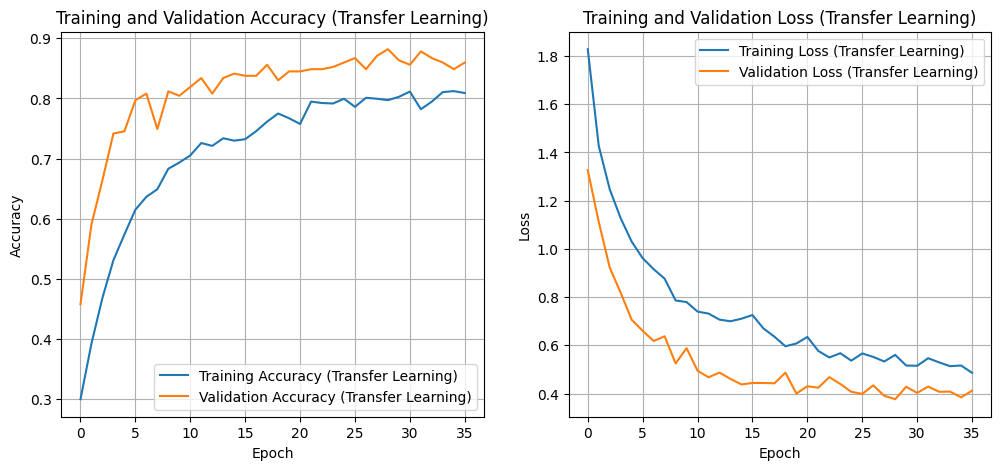

In [8]:
# Plot Akurasi dan Loss (Transfer Learning)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy (Transfer Learning)')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (Transfer Learning)')
plt.title('Training and Validation Accuracy (Transfer Learning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss (Transfer Learning)')
plt.plot(history.history['val_loss'], label='Validation Loss (Transfer Learning)')
plt.title('Training and Validation Loss (Transfer Learning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Fine-tuning Model
print("[INFO] Memulai Fase Fine-tuning")

# Buka Blokir (Unfreeze) base_model
base_model.trainable = True

# Lapisan yang akan di unfreeze
FINE_TUNE_AT = -75

# Bekukan kembali semua lapisan
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

print("[INFO] Base model (DenseNet201) sekarang trainable.")
print(f"[INFO] Total lapisan di base_model: {len(base_model.layers)}")
print(f"[INFO] Jumlah lapisan yang dibekukan: {len(base_model.layers[:FINE_TUNE_AT])}")

[INFO] Memulai Fase Fine-tuning
[INFO] Base model (DenseNet201) sekarang trainable.
[INFO] Total lapisan di base_model: 707
[INFO] Jumlah lapisan yang dibekukan: 632


In [10]:
# Learning Rate Sangat Kecil
fine_tune_learning_rate = 0.000008

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=fine_tune_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

print(f"[INFO] Model dikompilasi ulang dengan learning rate: {fine_tune_learning_rate}")

# Tampilkan Ringkasan Model Setelah Fine-tuning
print("[INFO] Ringkasan Arsitektur Model (Setelah Unfreeze untuk Fine-tuning)")
model.summary()

[INFO] Model dikompilasi ulang dengan learning rate: 8e-06
[INFO] Ringkasan Arsitektur Model (Setelah Unfreeze untuk Fine-tuning)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet201 (Functional)        │ (None, 7, 7, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1920)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     1,967,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,946,501 (79.90 MB)

 Trainable params: 5,303,621 (20.23 MB)

 Non-trainable params: 15,642,880 (59.67 MB)

In [11]:
# Total epoch untuk fine-tuning
TOTAL_FINE_TUNE_EPOCHS = history.epoch[-1] + 20

# EarlyStopping dan ModelCheckpoint untuk Fine-tuning
early_stopping_fine_tune = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_fine_tune = ModelCheckpoint(
    filepath='best_fine_tuned_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Training Model (Fine-tuning)
print(f"[INFO] Starting Model Training (Fine-tuning for 20 additional epochs)")

history_fine_tune = model.fit(
    train_generator,
    epochs=TOTAL_FINE_TUNE_EPOCHS,
    initial_epoch=history.epoch[-1],
    validation_data=validation_generator,
    callbacks=[early_stopping_fine_tune, checkpoint_fine_tune]
)

[INFO] Starting Model Training (Fine-tuning for 20 additional epochs)
Epoch 36/55
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.7169 - loss: 0.9529 
Epoch 36: val_accuracy improved from -inf to 0.86716, saving model to best_fine_tuned_model.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 582s 14s/step - accuracy: 0.7166 - loss: 0.9518 - val_accuracy: 0.8672 - val_loss: 0.3812
Epoch 37/55
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.7241 - loss: 0.8400 
Epoch 37: val_accuracy improved from 0.86716 to 0.87454, saving model to best_fine_tuned_model.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 558s 14s/step - accuracy: 0.7244 - loss: 0.8384 - val_accuracy: 0.8745 - val_loss: 0.3918
Epoch 38/55
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.7479 - loss: 0.7009 
Epoch 38: val_accuracy did not improve from 0.87454
40/40 ━━━━━━━━━━━━━━━━━━━━ 543s 14s/step - accuracy: 0.7483 - loss: 0.7002 - val_accuracy: 0.8561 - val_loss: 0.4017
Epoch 39/55
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.7763 - loss: 0.5911 
Epoch 39: val_accuracy did not improve from 0.87454
40/40 ━━━━━━━━━━━━━━━━━━━━ 542s 14s/step - accuracy: 0.7764 - loss: 0.5915 - val_accuracy: 0.8598 - val_loss: 0.4057
Epoch 40/55
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.8010 - loss: 0.6085 
Epoch 40: val_accuracy did not improve from 0.87454
40/40 ━━━━━━━━━━━━━━━━━━━━ 540s 14s/step - accuracy: 0.8010 - loss: 0.6079 - val_accuracy: 0.8598 - val_loss: 0.4123
Epoch 41/55
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.7886 - loss: 0.5691 
Epoch 41: val_accuracy did not i

In [12]:
# Evaluasi Model Validation Set (setelah Fine-tuning)
print("[INFO] Evaluating on Validation Set (After Fine-tuning)")
validation_generator.reset()
val_loss_fine_tuned, val_accuracy_fine_tuned = model.evaluate(validation_generator)
print(f"[INFO] Validation Loss: {val_loss_fine_tuned:.4f}")
print(f"[INFO] Validation Accuracy: {val_accuracy_fine_tuned*100:.2f}%")

[INFO] Evaluating on Validation Set (After Fine-tuning)
9/9 ━━━━━━━━━━━━━━━━━━━━ 79s 9s/step - accuracy: 0.8873 - loss: 0.3528
[INFO] Validation Loss: 0.3812
[INFO] Validation Accuracy: 86.72%


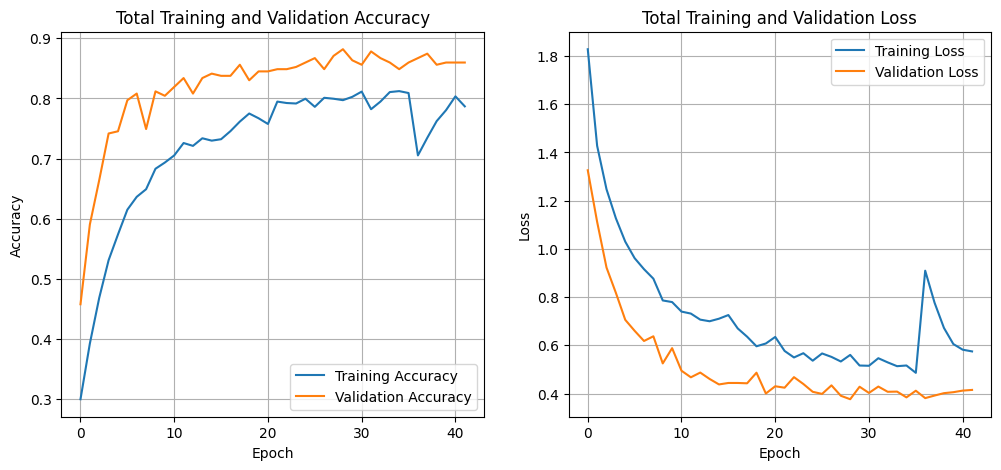

In [13]:
# Gabungkan riwayat pelatihan dari kedua fase untuk plotting yang lengkap
total_accuracy = history.history['accuracy'] + history_fine_tune.history['accuracy']
total_val_accuracy = history.history['val_accuracy'] + history_fine_tune.history['val_accuracy']
total_loss = history.history['loss'] + history_fine_tune.history['loss']
total_val_loss = history.history['val_loss'] + history_fine_tune.history['val_loss']

# Plot Akurasi dan Loss (Gabungan Fase 1 & 2)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(total_accuracy, label='Training Accuracy')
plt.plot(total_val_accuracy, label='Validation Accuracy')
plt.title('Total Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(total_loss, label='Training Loss')
plt.plot(total_val_loss, label='Validation Loss')
plt.title('Total Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

[INFO] Confusion Matrix Training Dataset (After Fine-tuning)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


40/40 ━━━━━━━━━━━━━━━━━━━━ 397s 10s/step


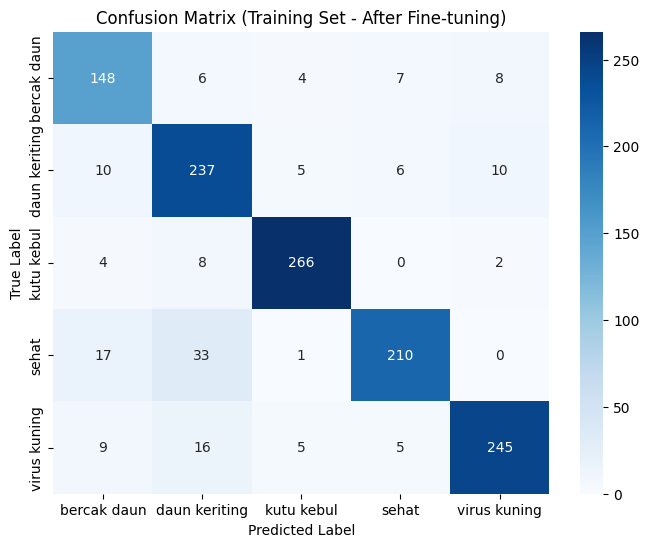


[INFO] Classification Report Training Dataset (After Fine-tuning)
               precision    recall  f1-score   support

  bercak daun       0.79      0.86      0.82       173
daun keriting       0.79      0.88      0.83       268
   kutu kebul       0.95      0.95      0.95       280
        sehat       0.92      0.80      0.86       261
 virus kuning       0.92      0.88      0.90       280

     accuracy                           0.88      1262
    macro avg       0.87      0.87      0.87      1262
 weighted avg       0.88      0.88      0.88      1262



In [14]:
# Confusion Matrix dan Classification Report untuk Training Dataset (setelah Fine-tuning)
print("[INFO] Confusion Matrix Training Dataset (After Fine-tuning)")
train_eval_generator.reset() # Pastikan generator direset sebelum prediksi
y_pred_probs_train_fine_tuned = model.predict(train_eval_generator)
y_pred_train_fine_tuned = np.argmax(y_pred_probs_train_fine_tuned, axis=1)
y_true_train_fine_tuned = train_eval_generator.classes

cm_train_fine_tuned = confusion_matrix(y_true_train_fine_tuned, y_pred_train_fine_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train_fine_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Training Set - After Fine-tuning)')
plt.show()

print("\n[INFO] Classification Report Training Dataset (After Fine-tuning)")
print(classification_report(y_true_train_fine_tuned, y_pred_train_fine_tuned, target_names=CLASS_NAMES))

# **EVALUASI**

In [15]:
# Evaluasi Model (Setelah Fine-tuning)
print("[INFO] Evaluating on Test Set (After Fine-tuning)")
test_generator.reset()
loss, accuracy = model.evaluate(test_generator)
print(f"[INFO] Test Loss: {loss:.4f}")
print(f"[INFO] Test Accuracy: {accuracy*100:.2f}%")

[INFO] Evaluating on Test Set (After Fine-tuning)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


9/9 ━━━━━━━━━━━━━━━━━━━━ 83s 9s/step - accuracy: 0.8305 - loss: 0.4688
[INFO] Test Loss: 0.4480
[INFO] Test Accuracy: 84.50%


[INFO] Confusion Matrix (Testing Set - After Fine-tuning)
9/9 ━━━━━━━━━━━━━━━━━━━━ 82s 9s/step


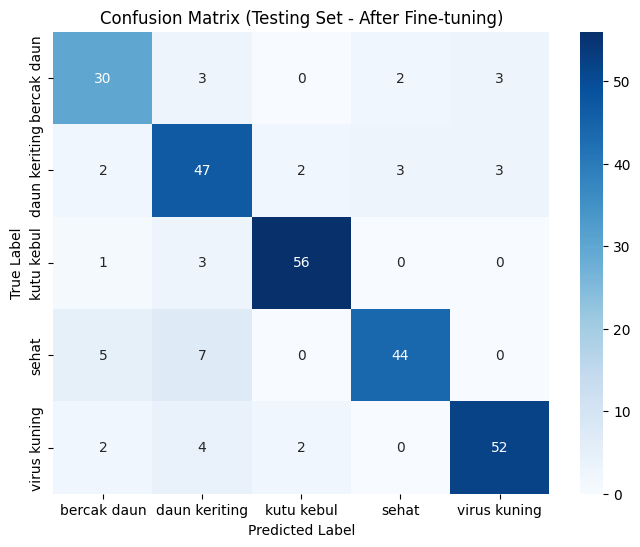

In [16]:
# Confusion Matrix dan Classification Report (Setelah Fine-tuning)
print("[INFO] Confusion Matrix (Testing Set - After Fine-tuning)")
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Testing Set - After Fine-tuning)')
plt.show()

In [17]:
print("[INFO] Classification Report (After Fine-tuning)")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

[INFO] Classification Report (After Fine-tuning)
               precision    recall  f1-score   support

  bercak daun       0.75      0.79      0.77        38
daun keriting       0.73      0.82      0.78        57
   kutu kebul       0.93      0.93      0.93        60
        sehat       0.90      0.79      0.84        56
 virus kuning       0.90      0.87      0.88        60

     accuracy                           0.85       271
    macro avg       0.84      0.84      0.84       271
 weighted avg       0.85      0.85      0.85       271



Please select an image file...



Saving 20250624_161229.jpg to 20250624_161229.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step


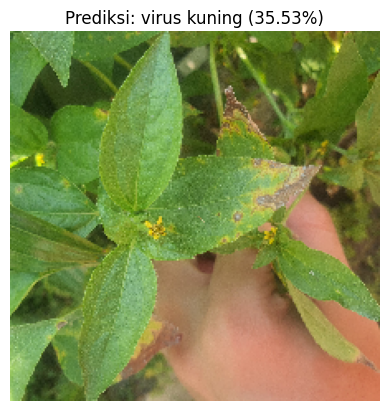


File yang diupload: 20250624_161229.jpg
Hasil Prediksi : virus kuning 
Keyakinan : 35.53%


('virus kuning', np.float32(35.534874))

In [ ]:
def predict_image():
    print("Please select an image file...\n")
    uploaded = files.upload()

    for fn in uploaded.keys():
        img = load_img(io.BytesIO(uploaded[fn]), target_size=(IMG_HEIGHT, IMG_WIDTH))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0

        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions[0])
        predicted_class_name = CLASS_NAMES[predicted_class_index]
        confidence = predictions[0][predicted_class_index] * 100

        plt.imshow(img)
        plt.title(f"Prediksi: {predicted_class_name} ({confidence:.2f}%)")
        plt.axis('off')
        plt.show()

        print(f"\nFile yang diupload: {fn}")
        print(f"Hasil Prediksi : {predicted_class_name} \nKeyakinan : {confidence:.2f}%")
        return predicted_class_name, confidence

predict_image()

# **Model H5**

In [18]:
# Tempat Penyimpanan Model
model_h5_path = '/content/drive/MyDrive/Model_ANN_FineTuned2.h5'

# Menyimpan seluruh model dalam format HDF5 (.h5)
model.save(model_h5_path)
print(f"Model berhasil disimpan dalam format H5: {model_h5_path}")

Model berhasil disimpan dalam format H5: /content/drive/MyDrive/Model_ANN_FineTuned2.h5
